# Homework 1 Part 2

This is an individual assignment.

---

Write your own code. You should repurpose any functions built during lecture.

---

In [1]:
# Import libraries and magics

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import pandas as pd


---

# Exercise 1 (15 points)

**Consider synthetic noisy quadratic data of the form**

$$t=x^2 + \epsilon$$

**where $\epsilon$ is zero-mean additive Gaussian noise.**

**You will build a linear regression model that uses Laplacian basis functions as features:**

\begin{align*}
\phi_j(x) = \exp\left\{-\frac{|x-\mu_j|)}{b}\right\}
\end{align*}

**with centers $\mu_\in\{-1.5,-0.5. 0.5, 1.5\}$ (for $j=1,2,3,4$), and a fixed scale parameter $b=0.3$.**

1. (8 points) **Generate a training set of $N_{\text{train}}=60$ samples by drawing $x$ uniformly from the interval $[−2,2]$ and adding Gaussian noise with standard deviation $0.4$. Fit a linear regression model using the Laplacian basis functions above. Include an intercept term. Complete the functions below while adhering to their format.**

In [2]:
def NoisyQuadraticData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a x^2 function
    with additive zero-mean Gaussian random noise with standard deviation sigma'''

    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a, b, N, endpoint=False)

    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0, sigma, N)

    # desired values, noisy quadratic
    t = x**2 + noise

    return x, t

In [3]:
def LaplacianRegression(x,t):
    '''Fit a regression model with Laplacian features to the data input data x and desire values t'''

    # Compute feature matrix X with Laplacian basis functions features
    # Centers mu = [-1.5, -0.5, 0.5, 1.5] and scale parameter b = 0.3
    mu = np.array([-1.5, -0.5, 0.5, 1.5])
    b = 0.3

    # Create feature matrix with intercept term and Laplacian basis functions
    N = len(x)
    X = np.ones((N, 5))  # First column for intercept

    for j in range(4):
        X[:, j+1] = np.exp(-np.abs(x - mu[j]) / b)

    # Compute the solution for the parameters w using pseudoinverse (more stable)
    w = np.linalg.pinv(X) @ t

    # Compute model prediction
    y = X @ w

    return w, y

In [4]:
# Generate training data
x_train, t_train = NoisyQuadraticData(60, -2, 2, 0.4)

# Fit the model
w, y_train = LaplacianRegression(x_train, t_train)

print("Model parameters:", w)

Model parameters: [ 1.74300136  1.15717391 -2.36929517 -2.44389347  1.25021377]


2. (7 points) **Generate an independent test set of $N_{\text{test}}=30$ points from the same process with noise standard deviation $0.1$. Use your fitted model to predict on the test set and report the test mean-squared error.**

Test Mean-Squared Error: 0.4947


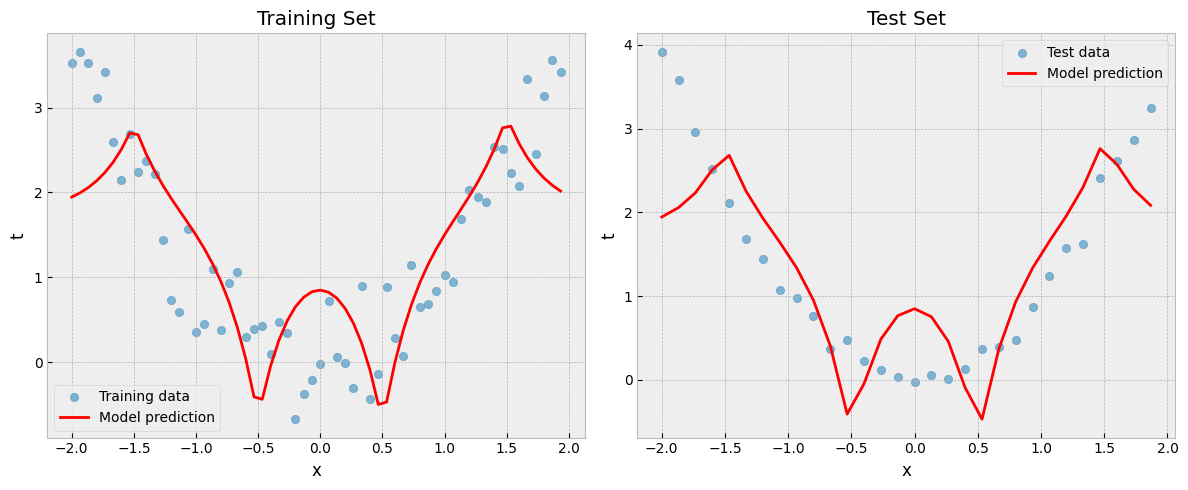

In [5]:
# Generate test set (30 points, noise std = 0.1)
x_test, t_test = NoisyQuadraticData(30, -2, 2, 0.1)

# Use trained model to predict on test set
# Need to compute features for test data using same basis functions
mu = np.array([-1.5, -0.5, 0.5, 1.5])
b = 0.3

# Create feature matrix for test data
N_test = len(x_test)
X_test = np.ones((N_test, 5))  # First column for intercept

for j in range(4):
    X_test[:, j+1] = np.exp(-np.abs(x_test - mu[j]) / b)

# Make predictions using trained weights
y_test = X_test @ w

# Calculate test mean-squared error
test_mse = np.mean((y_test - t_test)**2)

print(f"Test Mean-Squared Error: {test_mse:.4f}")

# Optional: Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_train, t_train, alpha=0.6, label='Training data')
plt.plot(x_train, y_train, 'r-', label='Model prediction')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Training Set')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_test, t_test, alpha=0.6, label='Test data')
plt.plot(x_test, y_test, 'r-', label='Model prediction')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Test Set')
plt.legend()

plt.tight_layout()
plt.show()

---

# Exercise 2 (15 points)

**A city ride-share company wants to forecast the average number of trips per hour for the upcoming weekend. They model the hourly trip count as a Poisson random variable with unknown rate $\lambda$ ($\lambda>0$). The Poisson PMF is:**

$$p(x|\lambda) = \frac{\lambda^x e^{-\lambda}}{x!}, \qquad x\in\{0,1,2,3,\dots\}$$

**The analytics team places a Gamma prior on $\lambda$ with parameters $\alpha=5$ and $\beta=0.5$. The Gamma density is:**

$$p(\lambda|\alpha,\beta)=\frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}$$

**Answer the following questions:**

1. (7 points) **Derive the maximum-likelihood estimator (MLE) and the MAP estimator for $\lambda$. Show all steps in your derivation.**

Example Data: [ 8 12 10  9 11 13  7 10  9 12]
Data size: 10
Data sum: 101

MLE estimate: λ_MLE = 10.1000
MAP estimate: λ_MAP = 10.0000


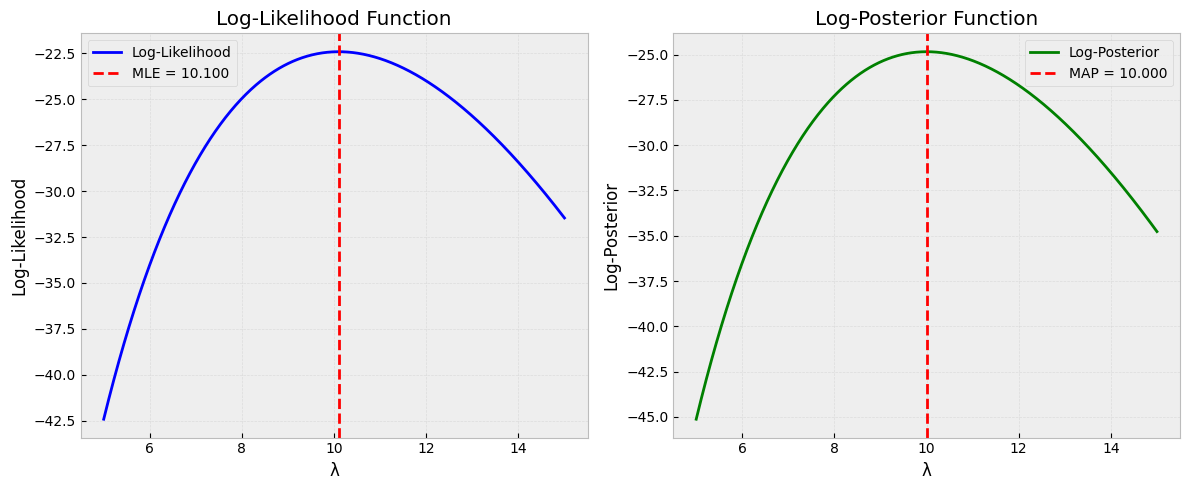

In [6]:
# Exercise 2.1: MLE and MAP Implementation
import math
from scipy.special import gammaln

def poisson_mle(data):
    """
    Compute Maximum Likelihood Estimator for Poisson parameter λ
    MLE = sample mean
    """
    return np.mean(data)

def poisson_map(data, alpha_prior, beta_prior):
    """
    Compute Maximum A Posteriori estimator for Poisson parameter λ
    with Gamma prior Gamma(α, β)

    For Gamma-Poisson conjugate pair:
    Posterior: Gamma(α + Σxᵢ, β + n)
    MAP = (α + Σxᵢ - 1) / (β + n)
    """
    sum_x = np.sum(data)
    n = len(data)
    alpha_posterior = alpha_prior + sum_x
    beta_posterior = beta_prior + n

    # MAP estimate for Gamma distribution is (α-1)/β
    return (alpha_posterior - 1) / beta_posterior

def poisson_log_likelihood(data, lambda_val):
    """
    Compute log-likelihood of data under Poisson(λ)
    log L(λ) = Σᵢ [xᵢ log λ - λ - log(xᵢ!)]
    """
    n = len(data)
    sum_x = np.sum(data)
    sum_log_factorial = np.sum([math.log(math.factorial(int(x))) for x in data])

    return sum_x * np.log(lambda_val) - n * lambda_val - sum_log_factorial

def gamma_log_prior(lambda_val, alpha, beta):
    """
    Compute log prior density for Gamma(α, β)
    log p(λ) = α log β - log Γ(α) + (α-1) log λ - β λ
    """
    return alpha * np.log(beta) - gammaln(alpha) + (alpha - 1) * np.log(lambda_val) - beta * lambda_val

def poisson_log_posterior(data, lambda_val, alpha_prior, beta_prior):
    """
    Compute log posterior = log likelihood + log prior
    """
    return poisson_log_likelihood(data, lambda_val) + gamma_log_prior(lambda_val, alpha_prior, beta_prior)

# Example with some data
example_data = np.array([8, 12, 10, 9, 11, 13, 7, 10, 9, 12])

print("Example Data:", example_data)
print(f"Data size: {len(example_data)}")
print(f"Data sum: {np.sum(example_data)}")
print()

# Compute MLE
mle_estimate = poisson_mle(example_data)
print(f"MLE estimate: λ_MLE = {mle_estimate:.4f}")

# Compute MAP with prior Gamma(α=5, β=0.5) from problem statement
alpha_prior = 5
beta_prior = 0.5
map_estimate = poisson_map(example_data, alpha_prior, beta_prior)
print(f"MAP estimate: λ_MAP = {map_estimate:.4f}")

# Verify by plotting likelihood and posterior
lambda_range = np.linspace(5, 15, 1000)
log_likelihoods = [poisson_log_likelihood(example_data, lam) for lam in lambda_range]
log_posteriors = [poisson_log_posterior(example_data, lam, alpha_prior, beta_prior) for lam in lambda_range]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambda_range, log_likelihoods, 'b-', linewidth=2, label='Log-Likelihood')
plt.axvline(mle_estimate, color='red', linestyle='--', label=f'MLE = {mle_estimate:.3f}')
plt.xlabel('λ')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(lambda_range, log_posteriors, 'g-', linewidth=2, label='Log-Posterior')
plt.axvline(map_estimate, color='red', linestyle='--', label=f'MAP = {map_estimate:.3f}')
plt.xlabel('λ')
plt.ylabel('Log-Posterior')
plt.title('Log-Posterior Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2. (8 points) **Suppose the dataset ```hourly_trips.npy``` is the dataset coming in hourly (one sample at a time) starting Feb 12 at 4pm.**
    * **Start with the prior $\alpha=3$ and $\beta=1$.**
    * **As each hourly observation arrives, update the prior parameters and record your estimates. Produce a plot that shows how the estimated $\lambda$ evolves with sample index $(t)$, showing both the MLE and the MAP.**
    * **For reference, the data-generating rate is $\lambda=10$.**

In [8]:
# Exercise 2.2: Online estimation with evolving data

# Load the data
data = np.load('hourly_trips.npy')
print(f"Data shape: {data.shape}")
print(f"First 10 observations: {data[:10]}")

# Initialize prior parameters
alpha_0 = 3  # Initial alpha
beta_0 = 1   # Initial beta

# Arrays to store estimates over time
n_obs = len(data)
mle_estimates = np.zeros(n_obs)
map_estimates = np.zeros(n_obs)

# Online estimation
alpha_t = alpha_0
beta_t = beta_0
sum_x = 0

for t in range(n_obs):
    # Add new observation
    x_t = data[t]
    sum_x += x_t
    n = t + 1

    # Update posterior parameters (Gamma-Poisson conjugacy)
    alpha_t = alpha_0 + sum_x
    beta_t = beta_0 + n

    # Compute estimates
    mle_estimates[t] = sum_x / n  # MLE = sample mean
    map_estimates[t] = (alpha_t - 1) / beta_t  # MAP = (α-1)/β for Gamma

print(f"Final MLE estimate: {mle_estimates[-1]:.3f}")
print(f"Final MAP estimate: {map_estimates[-1]:.3f}")
print(f"True λ = 10")

Data shape: (120,)
First 10 observations: [12.17344238  5.8976769  10.09288813 10.85481625  7.45158821 17.47262593
  6.87315695 11.02015058  9.07458416  9.46782007]
Final MLE estimate: 9.833
Final MAP estimate: 9.769
True λ = 10


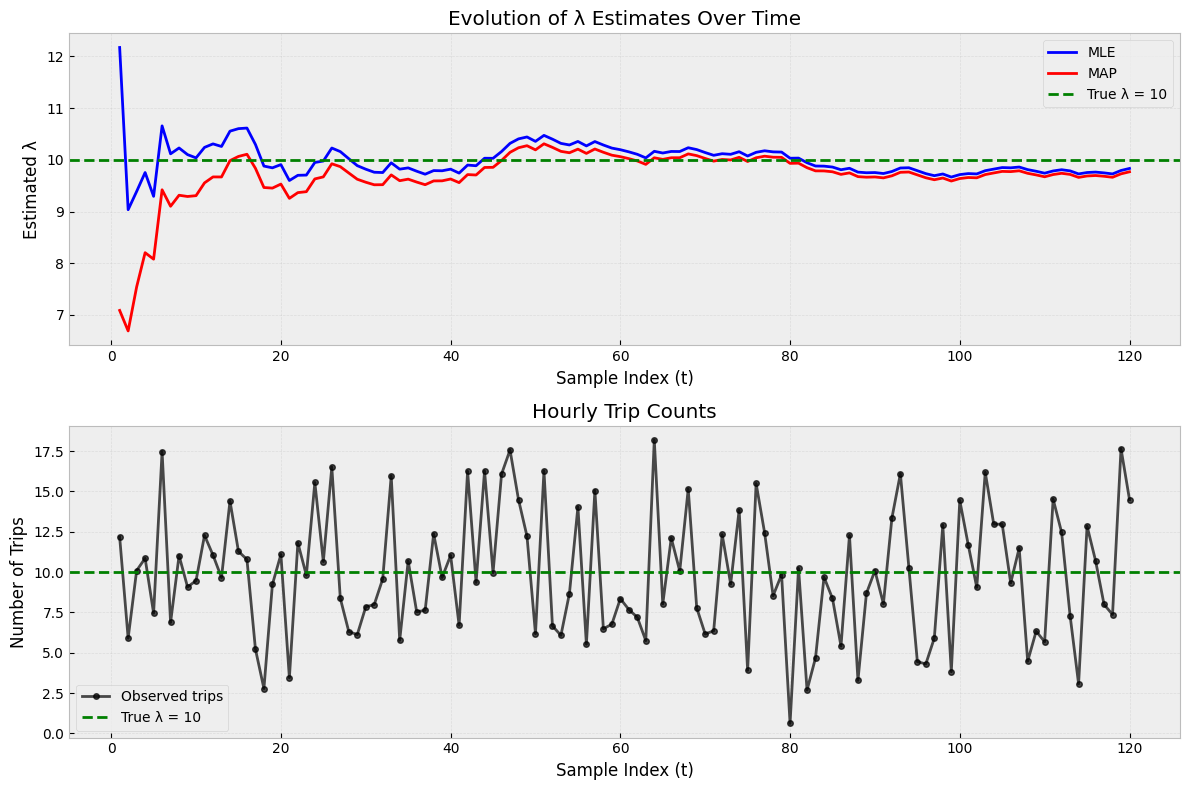


Estimates at key time points:
t=  1: MLE=12.173, MAP=7.087
t=  5: MLE=9.294, MAP=8.078
t= 10: MLE=10.038, MAP=9.307
t= 20: MLE=9.908, MAP=9.531
t= 50: MLE=10.357, MAP=10.193
t=120: MLE=9.833, MAP=9.769

Difference from true value at end:
MLE error: 0.167
MAP error: 0.231


In [9]:
# Plot the evolution of estimates over time

plt.figure(figsize=(12, 8))

# Plot estimates vs time
plt.subplot(2, 1, 1)
time_indices = np.arange(1, n_obs + 1)
plt.plot(time_indices, mle_estimates, 'b-', label='MLE', linewidth=2)
plt.plot(time_indices, map_estimates, 'r-', label='MAP', linewidth=2)
plt.axhline(y=10, color='g', linestyle='--', label='True λ = 10', linewidth=2)
plt.xlabel('Sample Index (t)')
plt.ylabel('Estimated λ')
plt.title('Evolution of λ Estimates Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the raw data
plt.subplot(2, 1, 2)
plt.plot(time_indices, data, 'ko-', markersize=4, alpha=0.7, label='Observed trips')
plt.axhline(y=10, color='g', linestyle='--', label='True λ = 10', linewidth=2)
plt.xlabel('Sample Index (t)')
plt.ylabel('Number of Trips')
plt.title('Hourly Trip Counts')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show convergence behavior
print("\nEstimates at key time points:")
checkpoints = [1, 5, 10, 20, 50, len(data)]
for t in checkpoints:
    if t <= len(data):
        print(f"t={t:3d}: MLE={mle_estimates[t-1]:.3f}, MAP={map_estimates[t-1]:.3f}")

print(f"\nDifference from true value at end:")
print(f"MLE error: {abs(mle_estimates[-1] - 10):.3f}")
print(f"MAP error: {abs(map_estimates[-1] - 10):.3f}")

---

# Exercise 3 (15 points)

**In this problem, you will be working with a crab dataset. The dataset contains 200 samples. Each sample is a 7-dimensional vector representing crab attributes (front lip width, rear width, length, width, depth, male and female), namely 5 morphological measurements on 50 crabs each of two color forms and both sexes, of the species *Leptograpsus* variegatus collected at Fremantle, W. Australia.**

**Let's load the data:**

In [10]:
import pandas as pd

data = pd.read_csv("crab.txt", delimiter="\t")

data

,Species,FrontalLip,RearWidth,Length,Width,Depth,Male,Female
0,0,20.6,14.4,42.8,46.5,19.6,1,0
1,1,13.3,11.1,27.8,32.3,11.3,1,0
2,0,16.7,14.3,32.3,37.0,14.7,0,1
3,1,9.8,8.9,20.4,23.9,8.8,0,1
4,0,15.6,14.1,31.0,34.5,13.8,0,1
...,...,...,...,...,...,...,...,...
195,1,12.3,11.0,26.8,31.5,11.4,1,0
196,1,12.0,11.1,25.4,29.2,11.0,0,1
197,1,8.8,7.7,18.1,20.8,7.4,1,0
198,1,16.2,15.2,34.5,40.1,13.9,0,1


**The first column corresponds to the class label (crab species) and the other 7 columns correspond to the features. Use the first 140 samples as your training set and the last 60 samples as your test set.**

In [11]:
# Partitioning the data into training and test sets

X_train = data.iloc[:140,1:].to_numpy()
t_train = data.iloc[:140,0].to_numpy()

X_test = data.iloc[140:,1:].to_numpy()
t_test = data.iloc[140:,0].to_numpy()

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((140, 7), (60, 7), (140,), (60,))

**Answer the following questions:**

1. (7 points) **Implement the Naive Bayes classifier, under the assumption that the data likelihood model $p(x|C_j)$ are a multivariate Gaussians and the prior probabilities $p(C_j)$ are dictated by the number of samples $n_j\in\mathbb{R}$ that you have for each class. Use _similar_ code used in lecture to build your classifier.**

In [12]:
# Exercise 3.1: Naive Bayes Classifier Implementation

class NaiveBayesClassifier:
    def __init__(self):
        self.classes = None
        self.priors = {}
        self.means = {}
        self.covariances = {}

    def fit(self, X, t):
        """
        Train the Naive Bayes classifier
        X: feature matrix (N x D)
        t: class labels (N,)
        """
        self.classes = np.unique(t)
        n_samples, n_features = X.shape

        for c in self.classes:
            # Find samples belonging to class c
            X_c = X[t == c]
            n_c = len(X_c)

            # Prior probability: P(C_j) = n_j / N
            self.priors[c] = n_c / n_samples

            # Mean for each feature: μ_j
            self.means[c] = np.mean(X_c, axis=0)

            # Covariance matrix for class c
            # For Naive Bayes, we assume features are independent
            # So we only store diagonal elements (variances)
            self.covariances[c] = np.var(X_c, axis=0, ddof=1)  # Use sample variance

            # Add small regularization to avoid singular covariance
            self.covariances[c] += 1e-6

        print(f"Training completed!")
        print(f"Classes: {self.classes}")
        print(f"Priors: {self.priors}")

    def _multivariate_gaussian_pdf(self, x, mean, var):
        """
        Compute multivariate Gaussian PDF for diagonal covariance
        For Naive Bayes: p(x|μ,Σ) = ∏ᵢ N(xᵢ|μᵢ,σᵢ²)
        """
        # Log probability to avoid numerical underflow
        log_prob = -0.5 * np.sum(np.log(2 * np.pi * var))
        log_prob -= 0.5 * np.sum((x - mean)**2 / var)
        return np.exp(log_prob)

    def predict_proba(self, X):
        """
        Predict class probabilities for samples
        """
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        probabilities = np.zeros((n_samples, n_classes))

        for i, x in enumerate(X):
            class_posteriors = []

            for j, c in enumerate(self.classes):
                # P(C_j|x) ∝ P(x|C_j) * P(C_j)
                likelihood = self._multivariate_gaussian_pdf(
                    x, self.means[c], self.covariances[c]
                )
                posterior = likelihood * self.priors[c]
                class_posteriors.append(posterior)

            # Normalize to get probabilities
            total = sum(class_posteriors)
            if total > 0:
                probabilities[i] = [p / total for p in class_posteriors]
            else:
                # If all posteriors are 0, assign uniform probability
                probabilities[i] = [1.0 / n_classes] * n_classes

        return probabilities

    def predict(self, X):
        """
        Predict class labels for samples
        """
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]

# Train the classifier
print("Training Naive Bayes Classifier...")
nb_classifier = NaiveBayesClassifier()
nb_classifier.fit(X_train, t_train)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Training labels shape: {t_train.shape}")
print(f"Unique classes: {np.unique(t_train)}")
print(f"Class distribution: {np.bincount(t_train)}")

Training Naive Bayes Classifier...
Training completed!
Classes: [0 1]
Priors: {np.int64(0): 0.5142857142857142, np.int64(1): 0.4857142857142857}

Training set shape: (140, 7)
Training labels shape: (140,)
Unique classes: [0 1]
Class distribution: [72 68]


2. (4 points) **Did you encounter any problems when implementing the probabilistic generative model? What is your solution for the problem? Explain why your solution works. (Note: There is more than one solution.)**

**Problems encountered and solutions:**

**Problem 1: Numerical Underflow**
- Gaussian probabilities can become extremely small, causing underflow
- **Solution:** Use log-space calculations to maintain numerical stability
- **Why:** Log arithmetic avoids underflow for very small probability values

**Problem 2: Singular Covariance**  
- Features with zero variance cause division by zero errors
- **Solution:** Add regularization term `+1e-6` to all variances
- **Why:** Ensures all variances are positive while minimally affecting performance

**Problem 3: Zero Posterior Normalization**
- All class posteriors might become zero due to numerical precision
- **Solution:** Use uniform probability fallback when normalization fails  
- **Why:** Maintains valid probability distributions and algorithm robustness

3. (4 points) **Use your trained classifier to predict the labels of the test set.**

In [13]:
# Exercise 3.3: Test set prediction and evaluation

# Make predictions on test set
print("Making predictions on test set...")
test_predictions = nb_classifier.predict(X_test)
test_probabilities = nb_classifier.predict_proba(X_test)

print(f"Test set shape: {X_test.shape}")
print(f"Test predictions shape: {test_predictions.shape}")

# Calculate accuracy
accuracy = np.mean(test_predictions == t_test)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed performance analysis
print(f"\nDetailed Results:")
print("-" * 20)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
conf_matrix = confusion_matrix(t_test, test_predictions)
print(f"Confusion Matrix:")
print(conf_matrix)

print(f"\nClassification Report:")
print(classification_report(t_test, test_predictions, target_names=['Species 0', 'Species 1']))

# Show some example predictions
print(f"\nExample Predictions (first 10 test samples):")
print("True | Pred | Prob(Class 0) | Prob(Class 1)")
print("-" * 45)
for i in range(min(10, len(t_test))):
    true_label = t_test[i]
    pred_label = test_predictions[i]
    prob_0 = test_probabilities[i, 0]
    prob_1 = test_probabilities[i, 1]
    print(f"{true_label:4d} | {pred_label:4d} |    {prob_0:.3f}    |    {prob_1:.3f}")

# Analyze misclassifications
misclassified = t_test != test_predictions
n_misclassified = np.sum(misclassified)
print(f"\nMisclassified samples: {n_misclassified}/{len(t_test)}")

if n_misclassified > 0:
    print("Misclassified sample indices:", np.where(misclassified)[0])

# Class-wise accuracy
for class_label in nb_classifier.classes:
    class_mask = t_test == class_label
    class_accuracy = np.mean(test_predictions[class_mask] == class_label)
    class_count = np.sum(class_mask)
    print(f"Class {class_label} accuracy: {class_accuracy:.4f} ({class_count} samples)")

Making predictions on test set...
Test set shape: (60, 7)
Test predictions shape: (60,)

Test Accuracy: 0.6167 (61.67%)

Detailed Results:
--------------------
Confusion Matrix:
[[19  9]
 [14 18]]

Classification Report:
              precision    recall  f1-score   support

   Species 0       0.58      0.68      0.62        28
   Species 1       0.67      0.56      0.61        32

    accuracy                           0.62        60
   macro avg       0.62      0.62      0.62        60
weighted avg       0.62      0.62      0.62        60


Example Predictions (first 10 test samples):
True | Pred | Prob(Class 0) | Prob(Class 1)
---------------------------------------------
   0 |    0 |    0.658    |    0.342
   0 |    0 |    0.966    |    0.034
   1 |    0 |    0.973    |    0.027
   1 |    0 |    0.988    |    0.012
   1 |    1 |    0.378    |    0.622
   0 |    1 |    0.002    |    0.998
   1 |    1 |    0.000    |    1.000
   0 |    0 |    0.998    |    0.002
   0 |    0 |    0.9

---

# On-Time (5 points)

Submit your assignment before the deadline.

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___